# **Complete repository step-by-step diagnostics. (Optimization Modules)**

In [1]:
# Add in validation utilities for testing and diagnostics.

from typing import Any, Callable, Optional
from IPython.display import Image
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

In [2]:
# Rehydrate the main setup code to ensure all modules are loaded for diagnostics.

import yaml
from dotenv import load_dotenv

from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()

with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

CACHE_DIR = cfg["global"]["cache_dir"]

print("[OPTIMIZATION SETUP] Loading CityGraph from cache...")
city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    cache_dir=CACHE_DIR,
    cache_prefix=city_graph_cfg["cache_prefix"]
)

print("[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...")
ddm_params = cfg["ddm"].copy()
ddm_params["cache_dir"] = CACHE_DIR

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=False
)

print("[OPTIMIZATION SETUP] Initializing Route Generator...")
generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=False
)

print("[OPTIMIZATION SETUP] Generating fresh baseline routes...")
num_routes = cfg.get("simulation", {}).get("num_routes", 5)
routes = [generator.generate(n_points=5) for _ in range(num_routes)]

print("[OPTIMIZATION SETUP] Building TravelGraph with new routes...")
tg = TravelGraph(
    cg=city,
    config=cfg["travel_graph"],
    routes=routes
)

print(f"[OPTIMIZATION SETUP] Ready. Base modules, {len(routes)} fresh routes, and TravelGraph loaded.")

[OPTIMIZATION SETUP] Loading CityGraph from cache...

[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...

[OPTIMIZATION SETUP] Initializing Route Generator...

[OPTIMIZATION SETUP] Generating fresh baseline routes...

[OPTIMIZATION SETUP] Building TravelGraph with new routes...

[OPTIMIZATION SETUP] Ready. Base modules, 5 fresh routes, and TravelGraph loaded.

## **Pheromone** (in pheromone.py, using the new SimulationEvaluator in simulation.py)

[VALIDATED] Initialize SimulationEvaluator: Executed successfully.

[EVALUATOR] Executing headless simulation for 3600 ticks...


[VALIDATED] Evaluate Baseline Route System: Executed successfully.

[RESULTS] Fitness Score: 3592727.32

[RESULTS] Completed Journeys: 229

...

[VALIDATED] Initialize PheromoneMatrix: Executed successfully.

[VALIDATED] Calculate Demand-Service Gaps: Executed successfully.

[VISUALIZATION] Rendering Route Infrastructure...

[VISUALIZATION] Rendering Pheromone Density and Service Gaps...

[VALIDATED] Draw Pheromone Matrix & Gaps: Executed successfully.

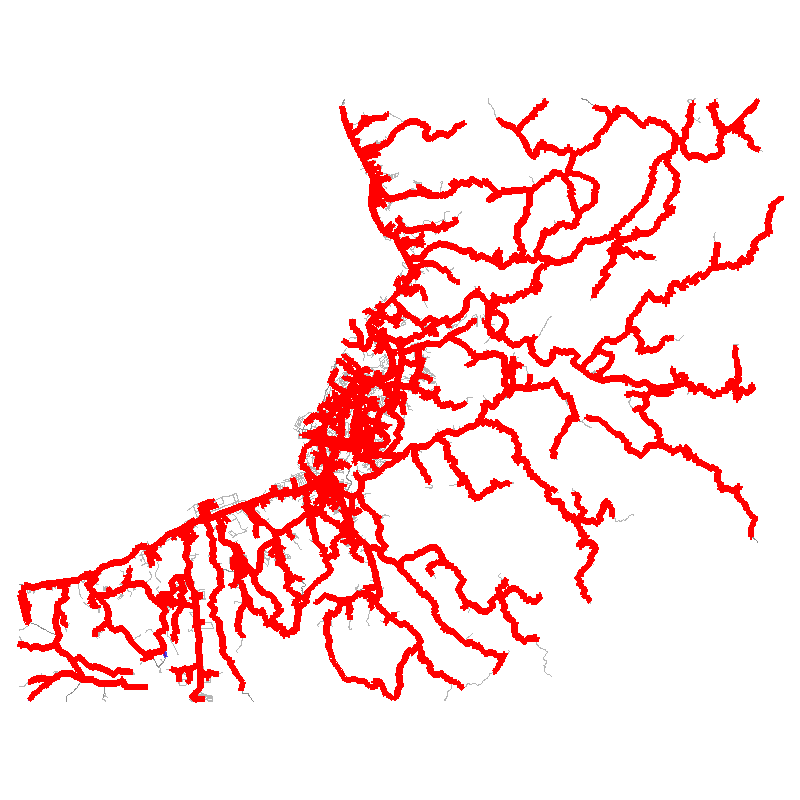

In [3]:
from utils.simulation import SimulationEvaluator
from utils.pheromone import PheromoneMatrix
from utils.route import RouteSystem
from IPython.display import display

# 1. Initialize Evaluator
evaluator = validate_call(
    "Initialize SimulationEvaluator", 
    True, 
    SimulationEvaluator, 
    cfg, city, tg, sampler
)

# 2. Run Baseline Simulation
result = validate_call(
    "Evaluate Baseline Route System", 
    True, 
    evaluator.evaluate, 
    routes, 
    verbose=True
)

if result:
    print(f"[RESULTS] Fitness Score: {result.fitness_score:.2f}")
    print(f"[RESULTS] Completed Journeys: {result.metrics['completed_count']}")
    print(f"[RESULTS] Incomplete Journeys: {result.metrics['incomplete_count']}")

    # 3. Extract Active Edges and Initialize Pheromones
    active_network_edges = set()
    for path, _ in result.recorded_paths:
        if path:
            active_network_edges.update(path)
    for route in routes:
        active_network_edges.update(route.path)
        
    pheromones = validate_call(
        "Initialize PheromoneMatrix", 
        True, 
        PheromoneMatrix,
        all_edges=active_network_edges, 
        config=cfg, 
        sim_result=result
    )

    gaps = validate_call(
        "Calculate Demand-Service Gaps",
        True,
        pheromones.calculate_demand_service_gaps,
        result.jeep_system
    )

    # 4. Render Route System and Pheromone Map
    context = city.get_bounds()
    base_map = city.draw(size=800)

    rs = RouteSystem()
    for r in routes:
        rs.add_route(r)
        
    print("[VISUALIZATION] Rendering Route Infrastructure...")
    route_map = rs.draw(context, base_map.copy(), line_width=4, dash_length=10)

    print("[VISUALIZATION] Rendering Pheromone Density and Service Gaps...")
    pheromone_map = validate_call(
        "Draw Pheromone Matrix & Gaps",
        True,
        pheromones.draw,
        context, 
        route_map.copy(), 
        gaps=gaps, 
        gap_threshold=0.5
    )

    if pheromone_map:
        display(pheromone_map)